## 1. Environment Setup and Project Paths

In [1]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# Set base paths
PROJECT_ROOT = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO"
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "dataset3")
CONFIG_PATH = os.path.join(PROJECT_ROOT, "config", "car_damage.yaml")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CONFIG_PATH:", CONFIG_PATH)

PROJECT_ROOT: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO
DATA_DIR: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3
CONFIG_PATH: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml


## 2. Dataset Exploration

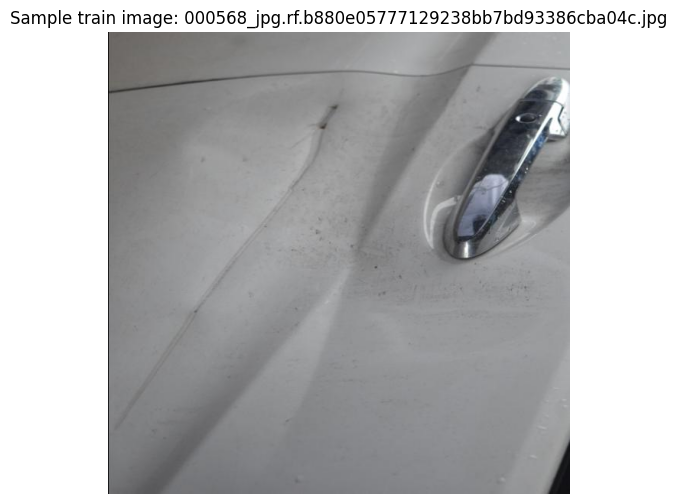

In [2]:
import random

train_images_dir = os.path.join(DATA_DIR, "train", "images")
sample_img_name = random.choice(os.listdir(train_images_dir))
sample_img_path = os.path.join(train_images_dir, sample_img_name)

img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Sample train image: {sample_img_name}")
plt.axis("off")
plt.show()

In [3]:
from collections import defaultdict

class_names = [
    "crack",
    "dent",
    "glass shatter",
    "lamp broken",
    "scratch",
    "tire flat"
]

train_labels_dir = os.path.join(DATA_DIR, "train", "labels")

class_counts = defaultdict(int)

for label_file in os.listdir(train_labels_dir):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(train_labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.read().strip().splitlines()

    for line in lines:
        parts = line.split()
        if len(parts) >= 1:
            cls_id = int(parts[0])
            class_counts[cls_id] += 1

print("\nClass Instance Counts in TRAIN Split:")
for cls_id, cls_name in enumerate(class_names):
    print(f"{cls_id}: {cls_name:15s} → {class_counts[cls_id]} instances")


Class Instance Counts in TRAIN Split:
0: crack           → 1813 instances
1: dent            → 5308 instances
2: glass shatter   → 1307 instances
3: lamp broken     → 1491 instances
4: scratch         → 7347 instances
5: tire flat       → 612 instances


## 3. GPU and CUDA Verification

In [5]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))

Torch version: 2.9.1+cu126
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 2050


## 4. YOLOv8s Model

In [6]:
model = YOLO("yolov8s.pt")
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

### 4.1 Train YOLOv8s on Car Damage Dataset

In [7]:
results = model.train(
    data=CONFIG_PATH,
    epochs=50,      
    imgsz=640,
    batch=8,
    name="car_damage_yolov8s",
    project=os.path.join(PROJECT_ROOT, "models", "runs"),
    patience=10,
    device=0,
)

New https://pypi.org/project/ultralytics/8.3.235 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, m

In [9]:
import pandas as pd

df = pd.read_csv(r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\results.csv")
print("Epochs recorded:", len(df))

Epochs recorded: 50


### 4.2 Validate YOLOv8s on Validation Set

In [10]:
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
model_best = YOLO(best_weights_path)

metrics_s = model_best.val(
    data=CONFIG_PATH,
    imgsz=640,
    split="val"
)

metrics_s

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 83.544.8 MB/s, size: 40.8 KB)
val: Scanning D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\valid\labels.cache... 812 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 812/812 812.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 2.3it/s 21.9s0.4ss
                   all        812       1670      0.767      0.678      0.721       0.57
                 crack        108        168      0.526      0.286      0.341      0.181
                  dent        317        446      0.691        0.5      0.575       0.33
         glass shatter        166        167      0.962      0.994      0.995      0.917
           lamp broken        110        112      0.843 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020122D23190>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

### 4.3 Summary Metrics for YOLOv8s

In [11]:
import numpy as np

mean_precision = float(np.mean(metrics_s.box.p))  # average over classes
mean_recall    = float(np.mean(metrics_s.box.r))  # average over classes

summary_s = {
    "mAP50": float(metrics_s.box.map50),
    "mAP50_95": float(metrics_s.box.map),
    "precision": mean_precision,
    "recall": mean_recall,
}

summary_s

{'mAP50': 0.7210464093511479,
 'mAP50_95': 0.5695254217744296,
 'precision': 0.7667514225342179,
 'recall': 0.6781977358950412}

### 4.4 F1-Score Calculation

In [12]:
import numpy as np

# Extract per-class precision and recall
P_s = np.array(metrics_s.box.p)
R_s = np.array(metrics_s.box.r)

# Compute per-class F1
F1_s = 2 * (P_s * R_s) / (P_s + R_s + 1e-6)

# Compute mean F1
mean_F1_s = float(np.mean(F1_s))

print("YOLOv8s Per-Class F1:", F1_s)
print("YOLOv8s Mean F1:", mean_F1_s)

YOLOv8s Per-Class F1: [    0.37023     0.58002     0.97795     0.85304     0.57359     0.92491]
YOLOv8s Mean F1: 0.7132890784245376


### 4.4 Per-Class Performance for YOLOv8s

In [13]:
class_names = [
    "crack",         # 0
    "dent",          # 1
    "glass shatter", # 2
    "lamp broken",   # 3
    "scratch",       # 4
    "tire flat"      # 5
]

for i, name in enumerate(class_names):
    print(f"{name:15s}  P={metrics_s.box.p[i]:.3f}  R={metrics_s.box.r[i]:.3f}")

crack            P=0.526  R=0.286
dent             P=0.691  R=0.500
glass shatter    P=0.962  R=0.994
lamp broken      P=0.843  R=0.863
scratch          P=0.611  R=0.540
tire flat        P=0.967  R=0.886


## 5. YOLOv8n Model

In [13]:
model_n = YOLO("yolov8n.pt")
model_n

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

### 5.1 Train YOLOv8n (Nano Model)

In [5]:
results_n = model_n.train(
    data=CONFIG_PATH,
    epochs=50,             
    imgsz=640,
    batch=16,               
    name="car_damage_yolov8n",
    project=os.path.join(PROJECT_ROOT, "models", "runs"),
    patience=10,
    device=0
)

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car_damage_yolov8n, nbs=64, nms=False, opset=None, optimize=False

### 5.2 Validate YOLOv8n on Validation Set

In [16]:
best_n_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8n\weights\best.pt"
model_n_best = YOLO(best_n_path)

metrics_n = model_n_best.val(
    data=CONFIG_PATH,
    imgsz=640,
    split="val"
)

metrics_n

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 252.899.7 MB/s, size: 37.2 KB)
val: Scanning D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\valid\labels.cache... 812 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 812/812  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 4.0it/s 12.7s0.3s
                   all        812       1670      0.263      0.223      0.254      0.206
                  dent        108        168          0          0   0.000891   0.000399
               scratch        317        446     0.0227     0.0269    0.00935    0.00424
                 crack        166        167      0.594      0.641      0.599      0.425
         glass shatter        110        112          0          0  

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020122D04610>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

### 5.3 Summary Metrics for YOLOv8n

In [17]:
import numpy as np

mean_precision_n = float(np.mean(metrics_n.box.p))
mean_recall_n    = float(np.mean(metrics_n.box.r))

summary_n = {
    "mAP50": float(metrics_n.box.map50),
    "mAP50_95": float(metrics_n.box.map),
    "precision": mean_precision_n,
    "recall": mean_recall_n,
}

summary_n

{'mAP50': 0.253830470452056,
 'mAP50_95': 0.20611360342978277,
 'precision': 0.262670224396808,
 'recall': 0.2230850780700052}

### 5.4 F1-Score Calculation

In [18]:
# Extract per-class precision and recall
P_n = np.array(metrics_n.box.p)
R_n = np.array(metrics_n.box.r)

# Compute per-class F1
F1_n = 2 * (P_n * R_n) / (P_n + R_n + 1e-6)

# Compute mean F1
mean_F1_n = float(np.mean(F1_n))

print("YOLOv8n Per-Class F1:", F1_n)
print("YOLOv8n Mean F1:", mean_F1_n)

YOLOv8n Per-Class F1: [          0    0.024622     0.61621           0           0     0.78975]
YOLOv8n Mean F1: 0.2384311968482394


## 6. Compare YOLOv8s vs YOLOv8n 

In [19]:
import pandas as pd

compare_df = pd.DataFrame([
    {
        "Model": "YOLOv8s",
        "mAP50": summary_s["mAP50"],
        "mAP50_95": summary_s["mAP50_95"],
        "Precision": summary_s["precision"],
        "Recall": summary_s["recall"],
        "F1": mean_F1_s
    },
    {
        "Model": "YOLOv8n",
        "mAP50": summary_n["mAP50"],
        "mAP50_95": summary_n["mAP50_95"],
        "Precision": summary_n["precision"],
        "Recall": summary_n["recall"],
        "F1": mean_F1_n
    }
])

compare_df

,Model,mAP50,mAP50_95,Precision,Recall,F1
0,YOLOv8s,0.721046,0.569525,0.766751,0.678198,0.713289
1,YOLOv8n,0.253830,0.206114,0.262670,0.223085,0.238431


## 7. Inference on Test Set Images
### Visualizing model predictions on dataset test images


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\test\images\000005_jpg.rf.46f3429885f8937a8de0236a12f661f8.jpg: 640x640 1 tire flat, 43.0ms
Speed: 9.2ms preprocess, 43.0ms inference, 17.7ms postprocess per image at shape (1, 3, 640, 640)


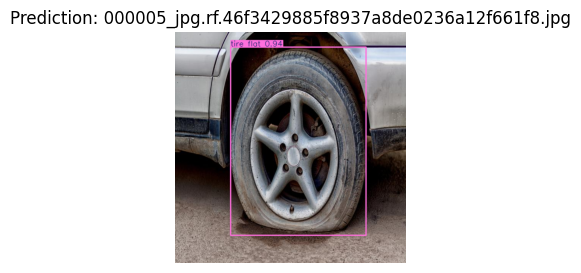


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\test\images\000014_jpg.rf.ebdfe334dcc39b1ee362e987002ac415.jpg: 640x640 1 dent, 1 glass shatter, 1 lamp broken, 1 scratch, 25.5ms
Speed: 2.6ms preprocess, 25.5ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


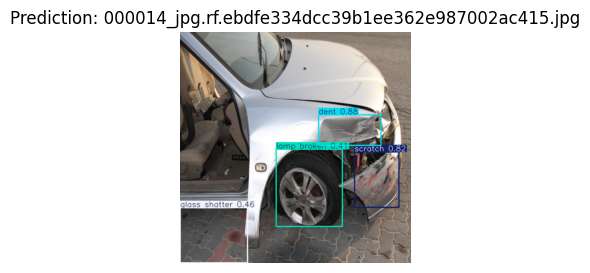


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\test\images\000019_jpg.rf.4428cf91965306df9868b77a7da04c3b.jpg: 640x640 2 scratchs, 24.5ms
Speed: 2.9ms preprocess, 24.5ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)


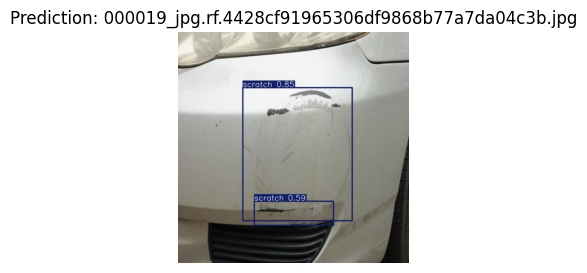


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\test\images\000020_jpg.rf.0f2336d57958bfe9a26f2e0cc0a02f6e.jpg: 640x640 2 scratchs, 25.9ms
Speed: 2.1ms preprocess, 25.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


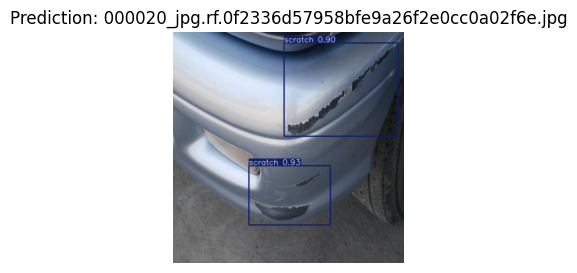


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\test\images\000032_jpg.rf.e4307085594b9d9870c66c7e3fc6f2b9.jpg: 640x640 (no detections), 25.4ms
Speed: 2.5ms preprocess, 25.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


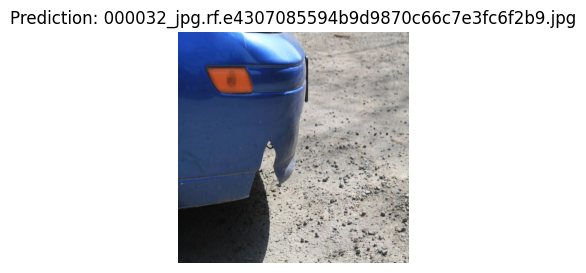


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\dataset3\test\images\000038_jpg.rf.13addc94a75b69ae93065a51d3405d31.jpg: 640x640 1 crack, 3 dents, 1 lamp broken, 25.0ms
Speed: 3.5ms preprocess, 25.0ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)


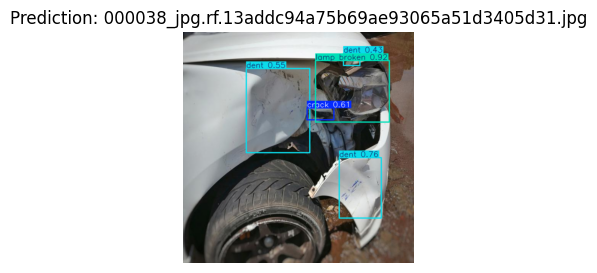

In [20]:
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
model_best = YOLO(best_weights_path)

test_dir = os.path.join(DATA_DIR, "test", "images")
test_imgs = os.listdir(test_dir)[:6]

for img_name in test_imgs:
    img_path = os.path.join(test_dir, img_name)
    results = model_best(img_path)

    for r in results:
        plotted = r.plot()
        plt.figure(figsize=(3, 3))
        plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediction: {img_name}")
        plt.axis("off")
        plt.show()

## 8. Generalisation Test on External Real-World Image
### Testing the model on an image not included in the dataset


image 1/1 C:\Users\ASUS\Downloads\damage_car.jpg: 448x640 1 dent, 212.4ms
Speed: 6.7ms preprocess, 212.4ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


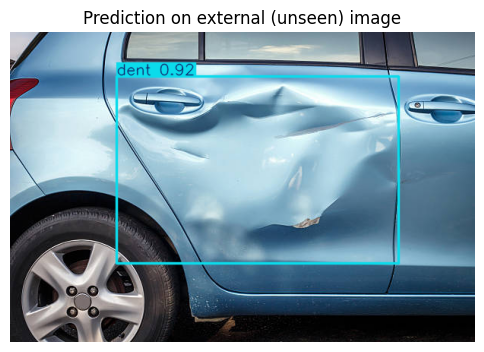

In [21]:
# Test on an external image not from the dataset
external_img_path = r"C:\Users\ASUS\Downloads\damage_car.jpg"

results = model_best(external_img_path)

for r in results:
    plotted = r.plot()
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("Prediction on external (unseen) image")
    plt.axis("off")
    plt.show()

## 9. Training History and Performance Curves
### Load YOLO training logs from results.csv

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\results.csv"

df = pd.read_csv(csv_path)

# Strip spaces from column names
df.columns = [c.strip() for c in df.columns]

print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


### 9.1 Training vs Validation Performance Plot

Using columns: metrics/mAP50(B) and train/box_loss


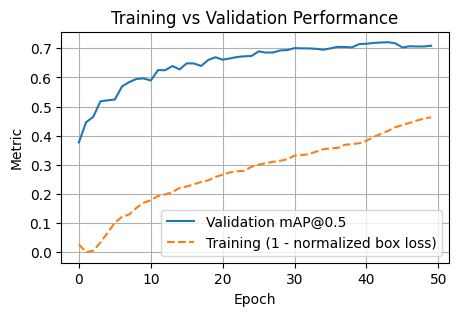

In [23]:
# Try to find the mAP and train loss columns automatically
mAP_col = [c for c in df.columns if "metrics/mAP50" in c][0]
train_loss_col = [c for c in df.columns if "train/box_loss" in c][0]

print("Using columns:", mAP_col, "and", train_loss_col)

plt.figure(figsize=(5, 3))

# Validation "accuracy" = mAP@0.5
plt.plot(df[mAP_col], label="Validation mAP@0.5")

# Training "accuracy" proxy = 1 - normalized box loss (so higher is better)
train_loss_norm = df[train_loss_col] / df[train_loss_col].max()
plt.plot(1 - train_loss_norm, label="Training (1 - normalized box loss)", linestyle="--")

plt.title("Training vs Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()

## 10. Real-Time Car Damage Detection Prototype
### Live detection using webcam (OpenCV + YOLOv8)

In [4]:
import cv2

# Use the best YOLOv8s weights for demo
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
demo_model = YOLO(best_weights_path)

# 0 = default webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Cannot open webcam.")
else:
    print("Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Run YOLO on the frame
        results = demo_model(frame)

        # Plot detections on the frame
        annotated_frame = results[0].plot()

        cv2.imshow("Car Damage Detection - Webcam Demo", annotated_frame)

        # Exit on 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Press 'q' to quit.

0: 480x640 1 dent, 1 scratch, 77.4ms
Speed: 2.5ms preprocess, 77.4ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 14.4ms
Speed: 2.2ms preprocess, 14.4ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 13.3ms
Speed: 1.3ms preprocess, 13.3ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 12.8ms
Speed: 1.4ms preprocess, 12.8ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 13.3ms
Speed: 1.2ms preprocess, 13.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 13.3ms
Speed: 1.4ms preprocess, 13.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 13.1ms
Speed: 1.3ms preprocess, 13.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 scratch, 13.7ms
Speed: 1.2ms preprocess, 13.7ms inference, 2.2ms postp

### 11. Detection on a Pre-recorded Video

In [5]:
video_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\car_damage_video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = demo_model(frame)
        annotated_frame = results[0].plot()

        cv2.imshow("Car Damage Detection - Video Demo", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


0: 384x640 3 scratchs, 2 glass shatters, 1 tire flat, 69.8ms
Speed: 2.4ms preprocess, 69.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 scratchs, 2 glass shatters, 1 lamp broken, 1 tire flat, 25.5ms
Speed: 3.3ms preprocess, 25.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 scratchs, 3 glass shatters, 1 tire flat, 24.9ms
Speed: 2.3ms preprocess, 24.9ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 scratchs, 2 glass shatters, 1 tire flat, 20.1ms
Speed: 2.2ms preprocess, 20.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 scratchs, 2 glass shatters, 1 tire flat, 19.6ms
Speed: 2.3ms preprocess, 19.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 scratchs, 1 crack, 2 glass shatters, 1 tire flat, 19.3ms
Speed: 2.7ms preprocess, 19.3ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dent, 3 